In [1]:
from glob import glob
import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
import shap
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt


/home/mahirwar/miniconda3/envs/kfold_amy_plaque1/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/mahirwar/miniconda3/envs/kfold_amy_plaque1/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/home/mahirwar/miniconda3/envs/kfold_amy_plaque1/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Data

In [63]:
oxford_data_feat = pd.read_csv("/gladstone/finkbeiner/steve/work/data/npsad_data/monika/Antibodies_detection/codes/crop_based/analysis/slide_features.csv")

In [64]:
oxford_data_feat.drop(["Unnamed: 0"],axis=1, inplace=True)

In [65]:
categorical_cols = ['brain_region', 'anitibody']  # update with your columns
oxford_data_feat.drop(columns=["pat_id","LBD_flag","Brain_bank"], axis=1, inplace=True)
oxford_data_feat.drop(columns=["slide_id"], axis=1, inplace=True)

In [66]:
df_encoded = pd.get_dummies(oxford_data_feat, columns=categorical_cols, drop_first=False)
df_encoded = df_encoded.astype(np.float32)  # Add this line


In [67]:
df_encoded = df_encoded.fillna(0)

In [68]:
numeric_cols = ['area_mean_mature_lb',
       'area_mean_pre_lb', 'area_mean_neg_lb', 'area_std_mature_lb',
       'area_std_pre_lb', 'area_std_neg_lb', 'perimeter_mean_mature_lb',
       'perimeter_mean_pre_lb', 'perimeter_mean_neg_lb',
       'perimeter_std_mature_lb', 'perimeter_std_pre_lb',
       'perimeter_std_neg_lb', 'eccentricity_mean_mature_lb',
       'eccentricity_mean_pre_lb', 'eccentricity_mean_neg_lb',
       'eccentricity_std_mature_lb', 'eccentricity_std_pre_lb',
       'eccentricity_std_neg_lb', 'major_axis_length_mean_mature_lb',
       'major_axis_length_mean_pre_lb', 'major_axis_length_mean_neg_lb',
       'major_axis_length_std_mature_lb', 'major_axis_length_std_pre_lb',
       'major_axis_length_std_neg_lb', 'minor_axis_length_mean_mature_lb',
       'minor_axis_length_mean_pre_lb', 'minor_axis_length_mean_neg_lb',
       'minor_axis_length_std_mature_lb', 'minor_axis_length_std_pre_lb',
       'minor_axis_length_std_neg_lb', 'solidity_mean_mature_lb',
       'solidity_mean_pre_lb', 'solidity_mean_neg_lb',
       'solidity_std_mature_lb', 'solidity_std_pre_lb', 'solidity_std_neg_lb',
       'extent_mean_mature_lb', 'extent_mean_pre_lb', 'extent_mean_neg_lb',
       'extent_std_mature_lb', 'extent_std_pre_lb', 'extent_std_neg_lb',
       'aspect_ratio_mean_mature_lb', 'aspect_ratio_mean_pre_lb',
       'aspect_ratio_mean_neg_lb', 'aspect_ratio_std_mature_lb',
       'aspect_ratio_std_pre_lb', 'aspect_ratio_std_neg_lb',
       'circularity_mean_mature_lb', 'circularity_mean_pre_lb',
       'circularity_mean_neg_lb', 'circularity_std_mature_lb',
       'circularity_std_pre_lb', 'circularity_std_neg_lb',
       'lb_count_mature_lb', 'lb_count_pre_lb', 'lb_count_neg_lb','brain_region_Amygdala', 'brain_region_EntCx',
       'brain_region_Striatum', 'anitibody_C110-115', 'anitibody_C34-45']

In [69]:
# Standardize numeric columns
scaler = StandardScaler()
df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

In [70]:
len(df_encoded.columns)

63

In [77]:
target_col = 'label'
# Target
y = df_encoded[target_col].values
X = df_encoded.drop(columns=[target_col]).values
feature_names = df_encoded.drop(columns=[target_col]).columns.tolist()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=45)

## Train Model

In [89]:
class SimpleNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 1)
        
    def forward(self, x):
        x = F.relu(self.fc1(x))
        return self.fc2(x)  # Binary output


In [175]:
def test_model(X_test_tensor,y_test_tensor, model):
    model.eval()  # Set model to evaluation mode

    with torch.no_grad():  # No gradient calculation
        outputs = model(X_test_tensor)
        loss = loss_fn(outputs, y_test_tensor)
        probs = torch.sigmoid(outputs)  # Convert logits to probabilities
        preds = (probs > 0.5).float()   # Convert probabilities to binary predictions

        correct = (preds == y_test_tensor).sum().item()
        total = y_test_tensor.size(0)

        accuracy = correct / total

    print(f"Test Accuracy: {accuracy:.4f}")
    return loss.item()
    

In [176]:
def train_model(X_train, y_train,X_test, y_test ):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)

    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1).to(device)

    train_loss_values = []
    test_loss_values = []
    model = SimpleNN(input_dim=X_train.shape[1]).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.BCEWithLogitsLoss()

    for epoch in range(250):
        model.train()
        optimizer.zero_grad()
        output = model(X_train_tensor)
        #print(output[0])
        loss = loss_fn(output, y_train_tensor)
        print(loss.item())
        loss.backward()
        optimizer.step()
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")
        train_loss_values.append(loss.item())
        val_loss = test_model(X_test_tensor,y_test_tensor, model)
        test_loss_values.append(val_loss)
    return train_loss_values, test_loss_values, model

In [111]:
def train_model(X_train, y_train,X_test, y_test ):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)

    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1).to(device)

    train_loss_values = []
    test_loss_values = []
    model = SimpleNN(input_dim=X_train.shape[1]).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.BCEWithLogitsLoss()

    for epoch in range(250):
        model.train()
        optimizer.zero_grad()
        output = model(X_train_tensor)
        #print(output[0])
        loss = loss_fn(output, y_train_tensor)
        print(loss.item())
        loss.backward()
        optimizer.step()
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")
        train_loss_values.append(loss.item())
        val_loss = test_model(model)
        test_loss_values.append(val_loss)
    return train_loss_values, test_loss_values, model
train_model() 

0.6682053804397583
Epoch 1, Loss: 0.6682
Test Accuracy: 0.4286
0.6575552225112915
Epoch 2, Loss: 0.6576
Test Accuracy: 0.3571
0.6473413705825806
Epoch 3, Loss: 0.6473
Test Accuracy: 0.4286
0.6375523209571838
Epoch 4, Loss: 0.6376
Test Accuracy: 0.4286
0.6282305121421814
Epoch 5, Loss: 0.6282
Test Accuracy: 0.4286
0.6192594766616821
Epoch 6, Loss: 0.6193
Test Accuracy: 0.5000
0.6106608510017395
Epoch 7, Loss: 0.6107
Test Accuracy: 0.5000
0.6023215055465698
Epoch 8, Loss: 0.6023
Test Accuracy: 0.5000
0.5941542387008667
Epoch 9, Loss: 0.5942
Test Accuracy: 0.5000
0.5861379504203796
Epoch 10, Loss: 0.5861
Test Accuracy: 0.6429
0.5782557129859924
Epoch 11, Loss: 0.5783
Test Accuracy: 0.6429
0.5704392194747925
Epoch 12, Loss: 0.5704
Test Accuracy: 0.6429
0.5626721382141113
Epoch 13, Loss: 0.5627
Test Accuracy: 0.6429
0.5549988150596619
Epoch 14, Loss: 0.5550
Test Accuracy: 0.6429
0.5473883152008057
Epoch 15, Loss: 0.5474
Test Accuracy: 0.6429
0.5398564338684082
Epoch 16, Loss: 0.5399
Test Ac

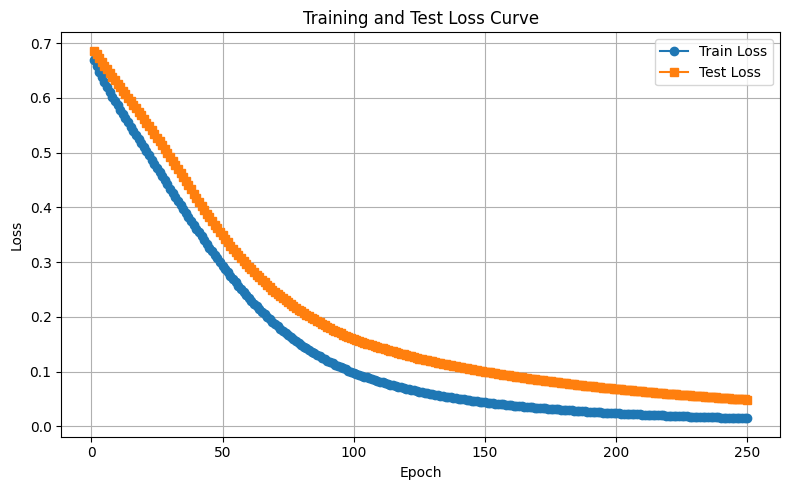

In [112]:
def plot_losses(train_loss_values, test_loss_values):
    epochs = range(1, len(train_loss_values) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_loss_values, label='Train Loss', marker='o')
    plt.plot(epochs, test_loss_values, label='Test Loss', marker='s')

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Test Loss Curve')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
plot_losses(train_loss_values, test_loss_values)

In [27]:
model.eval()  # Set model to evaluation mode

with torch.no_grad():  # No gradient calculation
    outputs = model(X_test_tensor)
    probs = torch.sigmoid(outputs)  # Convert logits to probabilities
    preds = (probs > 0.5).float()   # Convert probabilities to binary predictions

    correct = (preds == y_test_tensor).sum().item()
    total = y_test_tensor.size(0)

    accuracy = correct / total

print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 1.0000


In [113]:
len(y_test_tensor)

14

In [114]:
len(X_train_tensor)

54

In [115]:
class WrappedModel(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        logits = self.model(x)
        probs = torch.sigmoid(logits)
        return probs

wrapped_model = WrappedModel(model)
wrapped_model.eval()


WrappedModel(
  (model): SimpleNN(
    (fc1): Linear(in_features=62, out_features=64, bias=True)
    (fc2): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [116]:
wrapped_model = WrappedModel(model)
wrapped_model.eval()

WrappedModel(
  (model): SimpleNN(
    (fc1): Linear(in_features=62, out_features=64, bias=True)
    (fc2): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [143]:
background = X_train_tensor[:100]  # use 100 samples or fewer for background
explainer = shap.GradientExplainer(model, background)
shap_values = explainer.shap_values(X_test_tensor[:50])

In [144]:
shap_values

array([[[-2.41714365e-04],
        [ 1.34115594e-01],
        [ 1.70160935e-01],
        [-1.49145573e-02],
        [-1.07789105e-01],
        [-1.50523600e+00],
        [-1.02106123e-02],
        [-1.61327221e-01],
        [ 7.61078131e-01],
        [ 2.18558377e-02],
        [-7.77849020e-02],
        [ 4.40062420e-01],
        [-2.14534905e-01],
        [-7.61748540e-02],
        [ 1.86017509e-02],
        [ 3.86071541e-02],
        [-3.43124413e-01],
        [ 2.94724336e-01],
        [-5.44637068e-02],
        [-2.28306365e-01],
        [ 1.82675841e+00],
        [ 2.45630680e-02],
        [-7.07390865e-02],
        [ 1.43112014e+00],
        [-1.57564503e-01],
        [ 1.02018373e-01],
        [-7.87992423e-01],
        [ 1.31667320e-01],
        [-2.34770406e-01],
        [-1.12663340e+00],
        [-5.51855445e-04],
        [-2.15155039e-03],
        [-5.34317995e-03],
        [-3.63401562e-02],
        [-4.32702670e-02],
        [-9.51046886e-01],
        [-3.52990003e-01],
 

In [120]:
explainer = shap.KernelExplainer(lambda x: torch.sigmoid(model(torch.tensor(x, dtype=torch.float32).to(device))).cpu().detach().numpy(), 
                                 background.cpu().numpy())

shap_values = explainer.shap_values(X_test_tensor.cpu().numpy())

100%|██████████| 14/14 [00:01<00:00, 11.66it/s]


In [121]:
shap_values[0].shape


(62, 1)

In [123]:
len(df_encoded.columns[1:])

62

In [125]:
for i in range(len(shap_values)):
    positive_indices = np.where(shap_values[i] > 0)[0]
    feature_names = df_encoded.columns[1:].values
    positive_features = [feature_names[i] for i in positive_indices]
    print(positive_features)

[]
[]
[]
[]
['eccentricity_std_pre_lb', 'minor_axis_length_std_neg_lb', 'solidity_std_neg_lb', 'aspect_ratio_mean_pre_lb', 'circularity_mean_neg_lb', 'lb_count_mature_lb', 'lb_count_pre_lb', 'lb_count_neg_lb', 'anitibody_C110-115', 'anitibody_C34-45']
[]
['perimeter_std_pre_lb', 'minor_axis_length_std_pre_lb', 'solidity_std_neg_lb', 'circularity_mean_pre_lb', 'circularity_std_pre_lb', 'lb_count_mature_lb', 'lb_count_neg_lb', 'brain_region_EntCx', 'anitibody_C110-115', 'anitibody_C34-45']
[]
[]
['area_mean_pre_lb', 'area_std_pre_lb', 'perimeter_std_pre_lb', 'minor_axis_length_std_pre_lb', 'solidity_std_neg_lb', 'extent_std_neg_lb', 'aspect_ratio_mean_pre_lb', 'aspect_ratio_std_pre_lb', 'circularity_std_pre_lb', 'brain_region_EntCx']
[]
[]
['circularity_std_pre_lb', 'anitibody_C110-115']
[]


In [138]:
shap_df = pd.DataFrame(np.abs(shap_values.reshape((14,62))), columns =df_encoded.columns[1:] )


In [139]:
shap_df


,area_mean_mature_lb,area_mean_pre_lb,area_mean_neg_lb,area_std_mature_lb,area_std_pre_lb,area_std_neg_lb,perimeter_mean_mature_lb,perimeter_mean_pre_lb,perimeter_mean_neg_lb,perimeter_std_mature_lb,...,circularity_std_pre_lb,circularity_std_neg_lb,lb_count_mature_lb,lb_count_pre_lb,lb_count_neg_lb,brain_region_Amygdala,brain_region_EntCx,brain_region_Striatum,anitibody_C110-115,anitibody_C34-45
0,0.0,0.000000,0.0,0.0,0.000000,0.092417,0.0,0.0,0.0,0.0,...,0.073951,0.0,0.063984,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
1,0.0,0.000000,0.0,0.0,0.047147,0.000000,0.0,0.0,0.0,0.0,...,0.077788,0.0,0.051426,0.000000,0.000000,0.000000,0.000000,0.0,0.063609,0.047582
2,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.048182,0.0,0.000000,0.000000,0.062475,0.044059,0.000000,0.0,0.098214,0.082747
3,0.0,0.000000,0.0,0.0,0.083815,0.000000,0.0,0.0,0.0,0.0,...,0.040508,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
4,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.012871,0.044212,0.068536,0.000000,0.000000,0.0,0.062914,0.056266
5,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.089239,0.0,0.051922,0.028754,0.000000,0.030870,0.000000,0.0,0.090333,0.086592
6,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.055694,0.0,0.041550,0.000000,0.053513,0.000000,0.042225,0.0,0.053890,0.041063
7,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.091308,0.0,0.054800,0.064797,0.000000,0.043705,0.000000,0.0,0.065620,0.066074
8,0.0,0.000000,0.0,0.0,0.051071,0.000000,0.0,0.0,0.0,0.0,...,0.060086,0.0,0.067788,0.000000,0.042069,0.052154,0.000000,0.0,0.064086,0.060191
9,0.0,0.036787,0.0,0.0,0.078816,0.000000,0.0,0.0,0.0,0.0,...,0.034940,0.0,0.000000,0.000000,0.000000,0.000000,0.036616,0.0,0.000000,0.000000


In [140]:
feature_importance = shap_df.mean().sort_values(ascending=False)


In [146]:
feature_importance[:15]

circularity_std_pre_lb          0.056371
anitibody_C110-115              0.052425
anitibody_C34-45                0.039475
lb_count_neg_lb                 0.037312
area_std_pre_lb                 0.033418
solidity_std_neg_lb             0.032884
minor_axis_length_std_pre_lb    0.032742
circularity_mean_pre_lb         0.032337
lb_count_mature_lb              0.030882
lb_count_pre_lb                 0.019177
area_mean_pre_lb                0.016807
eccentricity_std_pre_lb         0.015543
perimeter_std_pre_lb            0.014011
brain_region_Amygdala           0.012199
aspect_ratio_mean_pre_lb        0.011367
dtype: float64

## Find feature correlation

In [151]:
df  = df_encoded[df_encoded.columns[1:]]

In [152]:
# Assuming df is your DataFrame
corr_matrix = df.corr().abs()

In [153]:
# Upper triangle of the correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

In [160]:
# Find features with correlation > threshold
threshold = 0.75
to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

In [161]:

print(to_drop)

# Drop them



['area_std_mature_lb', 'area_std_pre_lb', 'area_std_neg_lb', 'perimeter_mean_mature_lb', 'perimeter_mean_pre_lb', 'perimeter_mean_neg_lb', 'perimeter_std_mature_lb', 'perimeter_std_pre_lb', 'perimeter_std_neg_lb', 'eccentricity_mean_mature_lb', 'eccentricity_mean_pre_lb', 'eccentricity_mean_neg_lb', 'eccentricity_std_mature_lb', 'eccentricity_std_pre_lb', 'eccentricity_std_neg_lb', 'major_axis_length_mean_mature_lb', 'major_axis_length_mean_pre_lb', 'major_axis_length_mean_neg_lb', 'major_axis_length_std_mature_lb', 'major_axis_length_std_pre_lb', 'major_axis_length_std_neg_lb', 'minor_axis_length_mean_mature_lb', 'minor_axis_length_mean_pre_lb', 'minor_axis_length_mean_neg_lb', 'minor_axis_length_std_mature_lb', 'minor_axis_length_std_pre_lb', 'minor_axis_length_std_neg_lb', 'solidity_mean_mature_lb', 'solidity_mean_pre_lb', 'solidity_mean_neg_lb', 'solidity_std_mature_lb', 'solidity_std_pre_lb', 'solidity_std_neg_lb', 'extent_mean_mature_lb', 'extent_mean_pre_lb', 'extent_mean_neg_lb

In [164]:
df_reduced = df.drop(columns=to_drop[:-1])

In [165]:
df_reduced

,area_mean_mature_lb,area_mean_pre_lb,area_mean_neg_lb,aspect_ratio_mean_neg_lb,lb_count_mature_lb,lb_count_pre_lb,lb_count_neg_lb,brain_region_Amygdala,brain_region_EntCx,brain_region_Striatum,anitibody_C110-115,anitibody_C34-45
0,0.299881,1.341971,-0.530559,-0.136107,0.358919,0.108034,0.124388,1.125463,-0.811503,-0.439298,0.888523,-0.888523
1,-0.066794,0.922483,-0.523133,-0.046900,-0.233358,-0.258398,-0.073243,-0.888523,1.232282,-0.439298,0.888523,-0.888523
2,-0.199540,0.613601,1.255536,-0.151993,-0.383657,0.414307,-0.643015,-0.888523,1.232282,-0.439298,-1.125463,1.125463
3,0.379507,-0.389548,-0.540400,0.066018,-0.467275,-1.358789,-0.901883,-0.888523,-0.811503,2.276361,-1.125463,1.125463
4,-0.072459,1.275279,-0.518193,-0.096092,-0.541063,-0.477721,0.079043,-0.888523,-0.811503,2.276361,0.888523,-0.888523
...,...,...,...,...,...,...,...,...,...,...,...,...
63,0.157639,-1.093764,-0.318540,0.028567,0.134226,-1.143606,-0.682028,-0.888523,-0.811503,2.276361,-1.125463,1.125463
64,-1.091800,-1.109807,-0.529726,-0.167683,-0.131217,-0.080601,2.793364,1.125463,-0.811503,-0.439298,0.888523,-0.888523
65,-0.018743,1.181117,-0.435913,-0.137744,-0.387362,0.626323,-0.411092,1.125463,-0.811503,-0.439298,0.888523,-0.888523
66,-2.516827,-5.032846,-0.567005,-5.430708,-1.021674,-2.010061,-0.960193,1.125463,-0.811503,-0.439298,0.888523,-0.888523


In [168]:
target_col = 'label'
# Target
y = df_encoded[target_col].values
X = df_reduced.values
feature_names = df_reduced.columns.tolist()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=45)

In [174]:
X_test.shape

(14, 12)

In [178]:
train_loss_values, test_loss_values, model = train_model(X_train, y_train, X_test,y_test)

0.7193466424942017
Epoch 1, Loss: 0.7193
Test Accuracy: 0.3571
0.7149829268455505
Epoch 2, Loss: 0.7150
Test Accuracy: 0.4286
0.7106688022613525
Epoch 3, Loss: 0.7107
Test Accuracy: 0.4286
0.7064002752304077
Epoch 4, Loss: 0.7064
Test Accuracy: 0.4286
0.702174723148346
Epoch 5, Loss: 0.7022
Test Accuracy: 0.5714
0.6980056166648865
Epoch 6, Loss: 0.6980
Test Accuracy: 0.5714
0.6938846707344055
Epoch 7, Loss: 0.6939
Test Accuracy: 0.5714
0.6897995471954346
Epoch 8, Loss: 0.6898
Test Accuracy: 0.6429
0.6857700347900391
Epoch 9, Loss: 0.6858
Test Accuracy: 0.6429
0.6817692518234253
Epoch 10, Loss: 0.6818
Test Accuracy: 0.6429
0.6777896285057068
Epoch 11, Loss: 0.6778
Test Accuracy: 0.7143
0.6738528609275818
Epoch 12, Loss: 0.6739
Test Accuracy: 0.6429
0.6699448823928833
Epoch 13, Loss: 0.6699
Test Accuracy: 0.6429
0.6660666465759277
Epoch 14, Loss: 0.6661
Test Accuracy: 0.6429
0.6622267961502075
Epoch 15, Loss: 0.6622
Test Accuracy: 0.6429
0.6584174036979675
Epoch 16, Loss: 0.6584
Test Acc

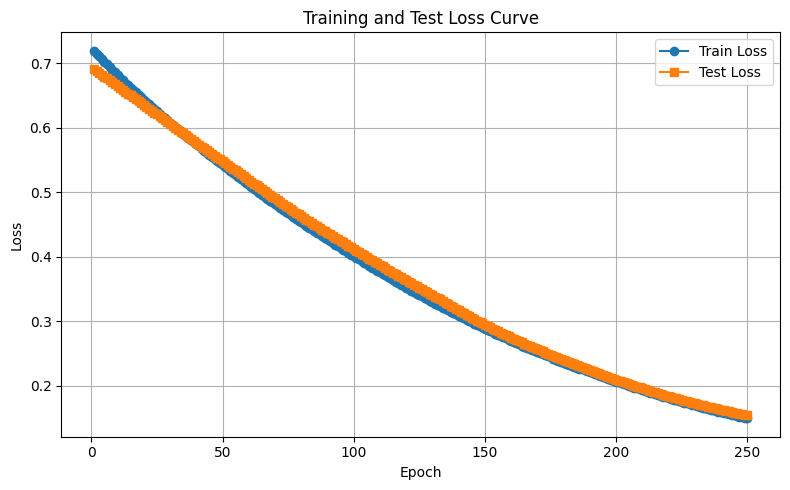

In [179]:
plot_losses(train_loss_values, test_loss_values)

In [180]:
wrapped_model = WrappedModel(model)
wrapped_model.eval()
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1).to(device)
background = X_train_tensor[:100]  # use 100 samples or fewer for background
#explainer = shap.GradientExplainer(model, background)
#shap_values = explainer.shap_values(X_test_tensor[:50])
explainer = shap.KernelExplainer(lambda x: torch.sigmoid(model(torch.tensor(x, dtype=torch.float32).to(device))).cpu().detach().numpy(), 
                                 background.cpu().numpy())

shap_values = explainer.shap_values(X_test_tensor.cpu().numpy())

100%|██████████| 14/14 [00:00<00:00, 15.34it/s]


In [182]:
shap_values.shape

(14, 12, 1)

In [185]:
shap_df = pd.DataFrame(shap_values.reshape((14,12)), columns =df_reduced.columns)
feature_importance = shap_df.mean().sort_values(ascending=False)
feature_importance

area_mean_neg_lb           -0.001793
brain_region_EntCx         -0.006194
lb_count_neg_lb            -0.006526
aspect_ratio_mean_neg_lb   -0.011013
area_mean_mature_lb        -0.014741
brain_region_Striatum      -0.016776
brain_region_Amygdala      -0.018901
area_mean_pre_lb           -0.028568
anitibody_C110-115         -0.033463
lb_count_pre_lb            -0.035030
anitibody_C34-45           -0.037519
lb_count_mature_lb         -0.052656
dtype: float64

## K-fold cross validation

In [186]:
from sklearn.model_selection import KFold

In [187]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

0.6664443016052246
Epoch 1, Loss: 0.6664
Test Accuracy: 0.6429
0.6621628999710083
Epoch 2, Loss: 0.6622
Test Accuracy: 0.6429
0.6579325199127197
Epoch 3, Loss: 0.6579
Test Accuracy: 0.6429
0.6537384390830994
Epoch 4, Loss: 0.6537
Test Accuracy: 0.6429
0.6495851874351501
Epoch 5, Loss: 0.6496
Test Accuracy: 0.6429
0.6454956531524658
Epoch 6, Loss: 0.6455
Test Accuracy: 0.7143
0.6414545774459839
Epoch 7, Loss: 0.6415
Test Accuracy: 0.7143
0.6374384760856628
Epoch 8, Loss: 0.6374
Test Accuracy: 0.7143
0.6334478855133057
Epoch 9, Loss: 0.6334
Test Accuracy: 0.7143
0.6294990181922913
Epoch 10, Loss: 0.6295
Test Accuracy: 0.7143
0.6255837678909302
Epoch 11, Loss: 0.6256
Test Accuracy: 0.7143
0.621703028678894
Epoch 12, Loss: 0.6217
Test Accuracy: 0.7143
0.6178435683250427
Epoch 13, Loss: 0.6178
Test Accuracy: 0.7143
0.6140223741531372
Epoch 14, Loss: 0.6140
Test Accuracy: 0.7143
0.610226571559906
Epoch 15, Loss: 0.6102
Test Accuracy: 0.7143
0.6064570546150208
Epoch 16, Loss: 0.6065
Test Accu

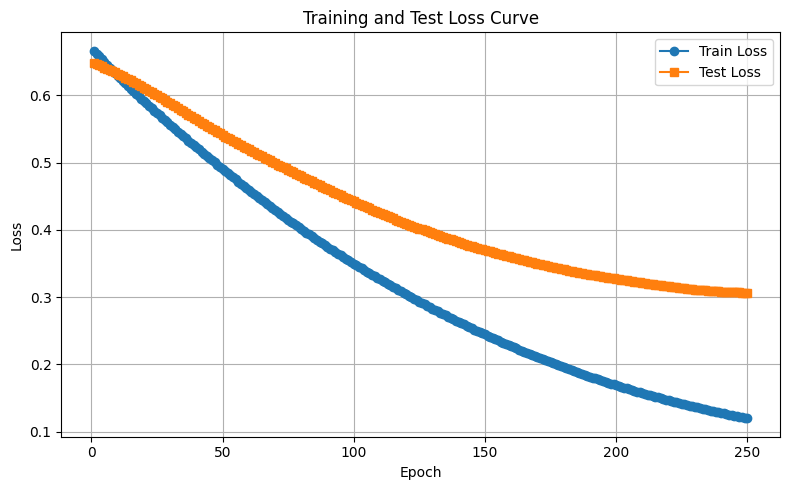

100%|██████████| 14/14 [00:00<00:00, 17.81it/s]


0.7167249917984009
Epoch 1, Loss: 0.7167
Test Accuracy: 0.2857
0.7111417055130005
Epoch 2, Loss: 0.7111
Test Accuracy: 0.3571
0.7056384682655334
Epoch 3, Loss: 0.7056
Test Accuracy: 0.3571
0.7002277970314026
Epoch 4, Loss: 0.7002
Test Accuracy: 0.3571
0.6949032545089722
Epoch 5, Loss: 0.6949
Test Accuracy: 0.4286
0.6896597146987915
Epoch 6, Loss: 0.6897
Test Accuracy: 0.5000
0.6844989657402039
Epoch 7, Loss: 0.6845
Test Accuracy: 0.5000
0.6794191598892212
Epoch 8, Loss: 0.6794
Test Accuracy: 0.5000
0.6744166016578674
Epoch 9, Loss: 0.6744
Test Accuracy: 0.4286
0.6694880127906799
Epoch 10, Loss: 0.6695
Test Accuracy: 0.4286
0.664636492729187
Epoch 11, Loss: 0.6646
Test Accuracy: 0.4286
0.6598526835441589
Epoch 12, Loss: 0.6599
Test Accuracy: 0.4286
0.6551446318626404
Epoch 13, Loss: 0.6551
Test Accuracy: 0.4286
0.6505040526390076
Epoch 14, Loss: 0.6505
Test Accuracy: 0.4286
0.6459238529205322
Epoch 15, Loss: 0.6459
Test Accuracy: 0.4286
0.6414002776145935
Epoch 16, Loss: 0.6414
Test Acc

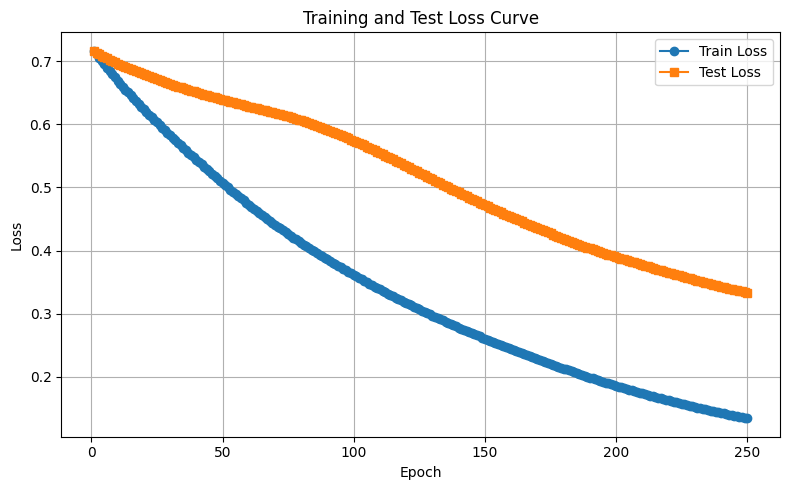

100%|██████████| 14/14 [00:00<00:00, 14.42it/s]


0.7031524181365967
Epoch 1, Loss: 0.7032
Test Accuracy: 0.5000
0.6988641023635864
Epoch 2, Loss: 0.6989
Test Accuracy: 0.5000
0.6946244239807129
Epoch 3, Loss: 0.6946
Test Accuracy: 0.5714
0.6904297471046448
Epoch 4, Loss: 0.6904
Test Accuracy: 0.5714
0.6862937211990356
Epoch 5, Loss: 0.6863
Test Accuracy: 0.5714
0.682202935218811
Epoch 6, Loss: 0.6822
Test Accuracy: 0.5714
0.6781426668167114
Epoch 7, Loss: 0.6781
Test Accuracy: 0.5714
0.6741163730621338
Epoch 8, Loss: 0.6741
Test Accuracy: 0.5714
0.6701290011405945
Epoch 9, Loss: 0.6701
Test Accuracy: 0.6429
0.666192352771759
Epoch 10, Loss: 0.6662
Test Accuracy: 0.6429
0.6623064875602722
Epoch 11, Loss: 0.6623
Test Accuracy: 0.6429
0.6584485173225403
Epoch 12, Loss: 0.6584
Test Accuracy: 0.6429
0.6546162962913513
Epoch 13, Loss: 0.6546
Test Accuracy: 0.6429
0.6508049964904785
Epoch 14, Loss: 0.6508
Test Accuracy: 0.6429
0.647020697593689
Epoch 15, Loss: 0.6470
Test Accuracy: 0.6429
0.6432581543922424
Epoch 16, Loss: 0.6433
Test Accur

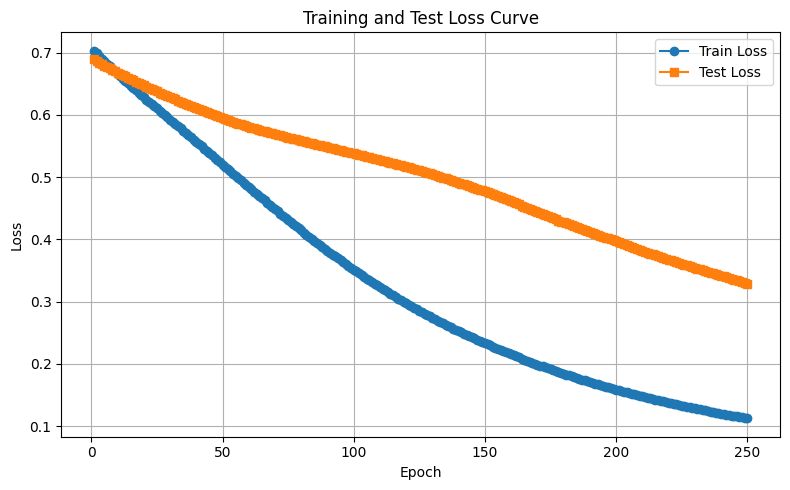

100%|██████████| 14/14 [00:00<00:00, 15.06it/s]


0.6827203631401062
Epoch 1, Loss: 0.6827
Test Accuracy: 0.6154
0.6779866814613342
Epoch 2, Loss: 0.6780
Test Accuracy: 0.6154
0.6733473539352417
Epoch 3, Loss: 0.6733
Test Accuracy: 0.6154
0.6687865853309631
Epoch 4, Loss: 0.6688
Test Accuracy: 0.6154
0.6643120050430298
Epoch 5, Loss: 0.6643
Test Accuracy: 0.6154
0.6599207520484924
Epoch 6, Loss: 0.6599
Test Accuracy: 0.6154
0.6556118726730347
Epoch 7, Loss: 0.6556
Test Accuracy: 0.6154
0.6513804793357849
Epoch 8, Loss: 0.6514
Test Accuracy: 0.6154
0.6472274661064148
Epoch 9, Loss: 0.6472
Test Accuracy: 0.6154
0.6431317329406738
Epoch 10, Loss: 0.6431
Test Accuracy: 0.6154
0.6390910744667053
Epoch 11, Loss: 0.6391
Test Accuracy: 0.6154
0.635111927986145
Epoch 12, Loss: 0.6351
Test Accuracy: 0.6154
0.6311793327331543
Epoch 13, Loss: 0.6312
Test Accuracy: 0.6923
0.6272914409637451
Epoch 14, Loss: 0.6273
Test Accuracy: 0.6923
0.6234576106071472
Epoch 15, Loss: 0.6235
Test Accuracy: 0.6923
0.6196705102920532
Epoch 16, Loss: 0.6197
Test Acc

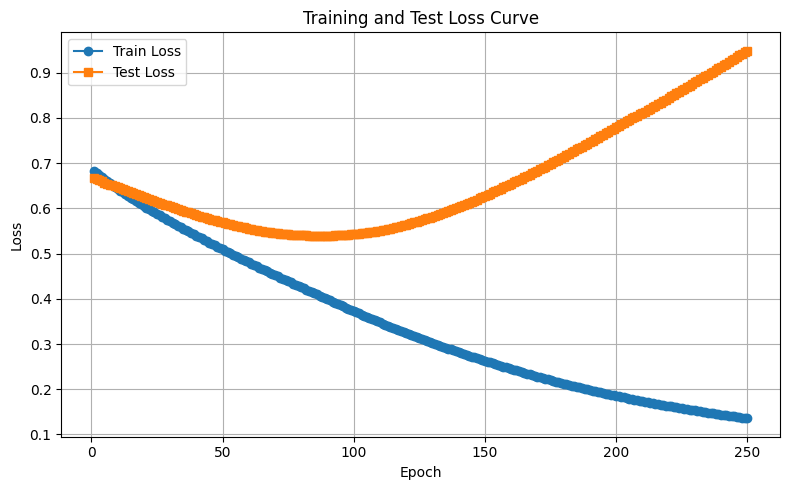

100%|██████████| 13/13 [00:00<00:00, 15.72it/s]


0.6574967503547668
Epoch 1, Loss: 0.6575
Test Accuracy: 0.6154
0.653639018535614
Epoch 2, Loss: 0.6536
Test Accuracy: 0.6154
0.6498245000839233
Epoch 3, Loss: 0.6498
Test Accuracy: 0.5385
0.6460522413253784
Epoch 4, Loss: 0.6461
Test Accuracy: 0.5385
0.6423150300979614
Epoch 5, Loss: 0.6423
Test Accuracy: 0.5385
0.6386117935180664
Epoch 6, Loss: 0.6386
Test Accuracy: 0.5385
0.6349316239356995
Epoch 7, Loss: 0.6349
Test Accuracy: 0.5385
0.6312740445137024
Epoch 8, Loss: 0.6313
Test Accuracy: 0.5385
0.6276360750198364
Epoch 9, Loss: 0.6276
Test Accuracy: 0.6154
0.6240271925926208
Epoch 10, Loss: 0.6240
Test Accuracy: 0.6154
0.6204429864883423
Epoch 11, Loss: 0.6204
Test Accuracy: 0.6923
0.6168884038925171
Epoch 12, Loss: 0.6169
Test Accuracy: 0.6923
0.6133522391319275
Epoch 13, Loss: 0.6134
Test Accuracy: 0.6923
0.6098320484161377
Epoch 14, Loss: 0.6098
Test Accuracy: 0.7692
0.6063264012336731
Epoch 15, Loss: 0.6063
Test Accuracy: 0.7692
0.6028438210487366
Epoch 16, Loss: 0.6028
Test Acc

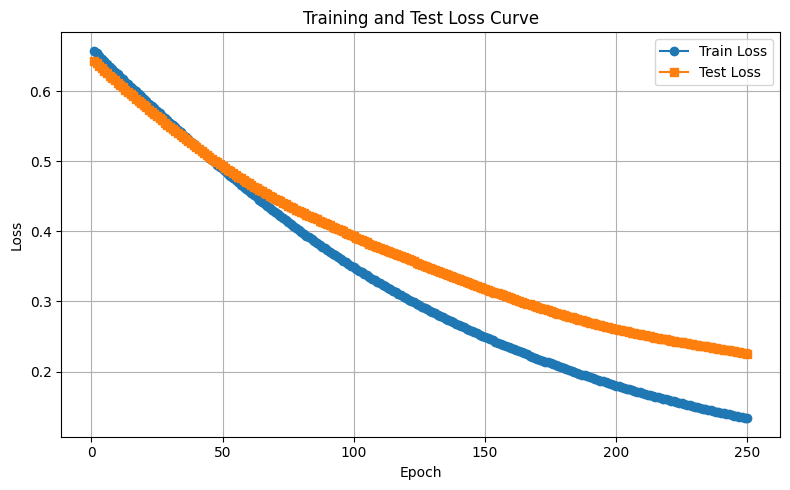

100%|██████████| 13/13 [00:00<00:00, 17.86it/s]


In [198]:
feature_importances = []
for fold, (train_index, test_index) in enumerate(kf.split(X), 1):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    train_loss_values, test_loss_values, model = train_model(X_train, y_train, X_test,y_test)
    plot_losses(train_loss_values, test_loss_values)
    wrapped_model = WrappedModel(model)
    wrapped_model.eval()
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)

    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1).to(device)
    background = X_train_tensor[:100]  # use 100 samples or fewer for background
    #explainer = shap.GradientExplainer(model, background)
    #shap_values = explainer.shap_values(X_test_tensor[:50])
    explainer = shap.KernelExplainer(lambda x: torch.sigmoid(model(torch.tensor(x, dtype=torch.float32).to(device))).cpu().detach().numpy(), 
                                    background.cpu().numpy())

    shap_values = explainer.shap_values(X_test_tensor.cpu().numpy())
    shap_df = pd.DataFrame(shap_values.reshape((shap_values.shape[0],12)), columns =df_reduced.columns)
    feature_importance = shap_df.mean().sort_values(ascending=False)
    feature_importances.append(feature_importance)

In [199]:
len(feature_importances)

5

In [200]:
feature_importances[0]

area_mean_pre_lb            0.050321
lb_count_mature_lb          0.037410
lb_count_pre_lb             0.011083
area_mean_mature_lb         0.010968
brain_region_Striatum       0.009401
lb_count_neg_lb            -0.001325
aspect_ratio_mean_neg_lb   -0.002833
area_mean_neg_lb           -0.007412
anitibody_C110-115         -0.022150
anitibody_C34-45           -0.027377
brain_region_EntCx         -0.037687
brain_region_Amygdala      -0.042241
dtype: float64

In [201]:
feature_importances[1]

anitibody_C110-115          0.030219
anitibody_C34-45            0.014590
area_mean_neg_lb            0.011576
brain_region_Amygdala       0.009578
brain_region_Striatum       0.003195
aspect_ratio_mean_neg_lb    0.002508
area_mean_mature_lb         0.001559
brain_region_EntCx         -0.008817
area_mean_pre_lb           -0.021967
lb_count_neg_lb            -0.025436
lb_count_mature_lb         -0.028269
lb_count_pre_lb            -0.050397
dtype: float64

In [202]:
feature_importances[2]

lb_count_pre_lb             0.106835
brain_region_Amygdala       0.047911
area_mean_neg_lb            0.022857
anitibody_C110-115          0.022244
lb_count_neg_lb             0.020710
anitibody_C34-45            0.014029
brain_region_EntCx          0.011955
lb_count_mature_lb          0.008824
area_mean_mature_lb        -0.000679
aspect_ratio_mean_neg_lb   -0.010749
brain_region_Striatum      -0.027859
area_mean_pre_lb           -0.076988
dtype: float64

In [203]:
feature_importances[3]

aspect_ratio_mean_neg_lb    0.116768
area_mean_pre_lb            0.040771
lb_count_neg_lb             0.016508
area_mean_neg_lb            0.008141
brain_region_EntCx          0.007322
brain_region_Striatum       0.003119
anitibody_C34-45            0.001112
brain_region_Amygdala       0.000136
anitibody_C110-115         -0.000833
lb_count_mature_lb         -0.001365
area_mean_mature_lb        -0.011966
lb_count_pre_lb            -0.032428
dtype: float64

In [204]:
feature_importances[4]

brain_region_EntCx          0.024932
area_mean_neg_lb            0.024643
area_mean_pre_lb            0.022799
lb_count_neg_lb             0.009778
aspect_ratio_mean_neg_lb    0.006088
area_mean_mature_lb        -0.002733
brain_region_Amygdala      -0.004460
anitibody_C110-115         -0.008041
brain_region_Striatum      -0.014199
lb_count_mature_lb         -0.025138
anitibody_C34-45           -0.027244
lb_count_pre_lb            -0.049249
dtype: float64

In [1]:
(0.9286+0.7692+1.000+0.7857+0.8571)/5

0.86812